In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anishaman07/agmarknet-india-commodity-prices-oct24-aug25")

print("Path to dataset files:", path)

100%|██████████| 11.2M/11.2M [00:00<00:00, 34.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/anishaman07/agmarknet-india-commodity-prices-oct24-aug25/versions/1


In [ ]:
import os
import pandas as pd

# List files in the downloaded directory
print(f"Files in {path}:\n{os.listdir(path)}")

Files in /root/.cache/kagglehub/datasets/anishaman07/agmarknet-india-commodity-prices-oct24-aug25/versions/1:
['agmarknet-india-commodity-prices-2024-2025']


In [ ]:
data_dir = os.path.join(path, 'agmarknet-india-commodity-prices-2024-2025')
print(f"Files in {data_dir}:\n{os.listdir(data_dir)}")

# Assuming the data is in a CSV file, let's load the first one we find
csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]

if csv_files:
    df = pd.read_csv(os.path.join(data_dir, csv_files[0]))
    print("\nFirst 5 rows of the dataset:")
    print(df.head())

    # Assuming there's a 'State' column, let's find unique states
    if 'State' in df.columns:
        unique_states = df['State'].unique()
        print("\nUnique States available in the dataset:")
        for state in unique_states:
            print(f"- {state}")
    else:
        print("\n'State' column not found. Please check the dataframe columns.")
        print(df.columns.tolist())
else:
    print("\nNo CSV files found in the data directory.")

Files in /root/.cache/kagglehub/datasets/anishaman07/agmarknet-india-commodity-prices-oct24-aug25/versions/1/agmarknet-india-commodity-prices-2024-2025:
['agmarknet_india_historical_prices_2024_2025.csv', 'LICENSE.txt', 'README.md']

First 5 rows of the dataset:
   Sl no. District Name Market Name Commodity Variety Grade  \
0       1       Auraiya     Achalda     Wheat    Dara   FAQ   
1       2       Auraiya     Achalda     Wheat    Dara   FAQ   
2       3       Auraiya     Achalda     Wheat    Dara   FAQ   
3       4       Auraiya     Achalda     Wheat    Dara   FAQ   
4       5       Auraiya     Achalda     Wheat    Dara   FAQ   

   Min Price (Rs./Quintal)  Max Price (Rs./Quintal)  \
0                   2350.0                   2550.0   
1                   2400.0                   2500.0   
2                   2400.0                   2500.0   
3                   2400.0                   2520.0   
4                   2400.0                   2550.0   

   Modal Price (Rs./Quintal

## AI/ML Pipeline: Part 1 - Data Selection and Preprocessing

We will now filter the data for **Gujarat** and prepare it for time-series forecasting. Key steps include:
1. Filtering by state.
2. Converting 'Price Date' to datetime objects.
3. Handling missing values.
4. Visualizing price trends.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for Gujarat
df_gujarat = df[df['State'] == 'Gujarat'].copy()

# Convert Price Date to datetime
# The data format is 'DD Mon YYYY' (e.g., '05 Apr 2025')
df_gujarat['Price Date'] = pd.to_datetime(df_gujarat['Price Date'])

# Sort by date for time-series analysis
df_gujarat = df_gujarat.sort_values('Price Date')

print(f"Total records for Gujarat: {len(df_gujarat)}")
display(df_gujarat.head())

Total records for Gujarat: 112980


,Sl no.,District Name,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date,State
1001146,2868,Vadodara(Baroda),Vadodara(Sayajipura),Ginger(Green),Other,FAQ,3000.0,9000.0,6050.0,2024-08-15,Gujarat
835066,1909,Vadodara(Baroda),Padra,Bhindi(Ladies Finger),Other,FAQ,1000.0,1500.0,1250.0,2024-08-15,Gujarat
1000015,1737,Rajkot,Rajkot(Veg.Sub Yard),Ginger(Green),Green Ginger,FAQ,4500.0,9000.0,6750.0,2024-08-15,Gujarat
835056,1899,Navsari,Navsari,Bhindi(Ladies Finger),Bhindi,FAQ,2500.0,3000.0,2750.0,2024-08-15,Gujarat
542653,1534,Bharuch,Ankleshwar,Cauliflower,Cauliflower,FAQ,1200.0,2800.0,1600.0,2024-08-15,Gujarat


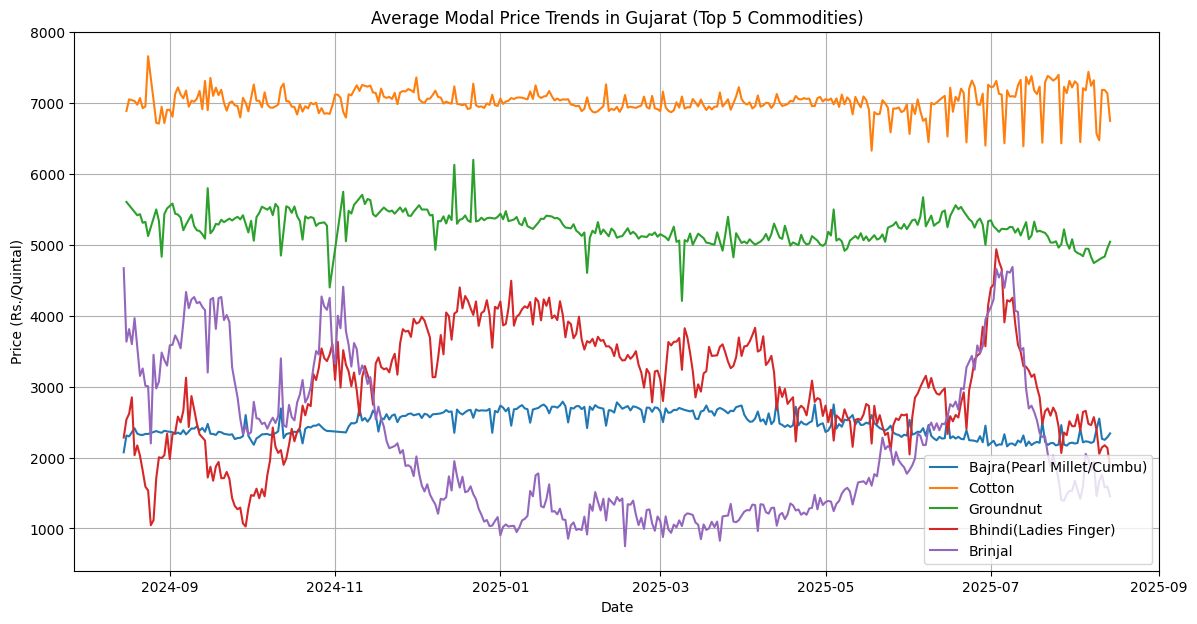

In [ ]:
# Visualize Modal Price trends for the top 5 most frequent commodities in Gujarat
top_commodities = df_gujarat['Commodity'].value_counts().nlargest(5).index.tolist()

plt.figure(figsize=(14, 7))
for commodity in top_commodities:
    subset = df_gujarat[df_gujarat['Commodity'] == commodity]
    # Resample or group by date to get a cleaner line plot if multiple markets exist
    daily_avg = subset.groupby('Price Date')['Modal Price (Rs./Quintal)'].mean()
    plt.plot(daily_avg.index, daily_avg.values, label=commodity)

plt.title('Average Modal Price Trends in Gujarat (Top 5 Commodities)')
plt.xlabel('Date')
plt.ylabel('Price (Rs./Quintal)')
plt.legend()
plt.grid(True)
plt.show()

## AI/ML Pipeline: Part 2 - Data Cleaning and Preprocessing

Before training, we must ensure the data is reliable. We will:
1. Check for and handle missing values.
2. Remove duplicate entries.
3. Filter out unrealistic price outliers (e.g., zero prices).
4. Standardize commodity and market names.

In [ ]:
# 1. Check for missing values
print("Missing values per column:\n", df_gujarat.isnull().sum())

# 2. Drop duplicates if any
initial_len = len(df_gujarat)
df_gujarat = df_gujarat.drop_duplicates()
print(f"\nRemoved {initial_len - len(df_gujarat)} duplicate rows.")

# 3. Handle Price Outliers
# Prices should be greater than zero. We'll filter out non-positive prices.
price_cols = ['Min Price (Rs./Quintal)', 'Max Price (Rs./Quintal)', 'Modal Price (Rs./Quintal)']
for col in price_cols:
    df_gujarat = df_gujarat[df_gujarat[col] > 0]

# Use Z-score or IQR to remove extreme outliers that might be data entry errors
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# We'll apply outlier removal per commodity to be fair to different crop values
df_cleaned = pd.DataFrame()
for commodity in df_gujarat['Commodity'].unique():
    comm_df = df_gujarat[df_gujarat['Commodity'] == commodity]
    comm_df = remove_outliers(comm_df, 'Modal Price (Rs./Quintal)')
    df_cleaned = pd.concat([df_cleaned, comm_df])

print(f"\nRecords after outlier removal: {len(df_cleaned)} (from {len(df_gujarat)})")

# 4. Final Data Summary
display(df_cleaned.describe())

Missing values per column:
 Sl no.                       0
District Name                0
Market Name                  0
Commodity                    0
Variety                      0
Grade                        0
Min Price (Rs./Quintal)      0
Max Price (Rs./Quintal)      0
Modal Price (Rs./Quintal)    0
Price Date                   0
State                        0
dtype: int64

Removed 0 duplicate rows.

Records after outlier removal: 108381 (from 112803)


,Sl no.,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date
count,108381.000000,108381.000000,108381.000000,108381.000000,108381
mean,3775.182089,3569.656992,4627.702411,4173.270098,2025-02-20 00:24:00.518172160
min,1.000000,100.000000,200.000000,150.000000,2024-08-15 00:00:00
25%,1507.000000,2000.000000,2525.000000,2325.000000,2024-11-29 00:00:00
50%,3264.000000,3000.000000,4075.000000,3750.000000,2025-02-21 00:00:00
75%,5370.000000,5000.000000,6080.000000,5650.000000,2025-05-19 00:00:00
max,12547.000000,35000.000000,37755.000000,35500.000000,2025-08-14 00:00:00
std,2813.429119,2439.349951,3067.852356,2742.274700,NaN


## AI/ML Pipeline: Part 3 - Feature Engineering & Model Training

Now that we have clean data, we will:
1. **Extract Temporal Features**: Year, Month, Day, and Day of Week.
2. **Categorical Encoding**: Use Label Encoding for Districts and Commodities.
3. **Time-Series Split**: Train on the first 80% of data (chronologically) and test on the remaining 20%.
4. **XGBoost Training**: Train a gradient boosting model optimized for regression.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Prepare feature set from cleaned data
df_ml = df_cleaned.copy().sort_values('Price Date')

# 1. Feature Engineering
df_ml['Year'] = df_ml['Price Date'].dt.year
df_ml['Month'] = df_ml['Price Date'].dt.month
df_ml['Day'] = df_ml['Price Date'].dt.day
df_ml['DayOfWeek'] = df_ml['Price Date'].dt.dayofweek

# 2. Encoding
le_commodity = LabelEncoder()
le_district = LabelEncoder()
df_ml['Commodity_Enc'] = le_commodity.fit_transform(df_ml['Commodity'])
df_ml['District_Enc'] = le_district.fit_transform(df_ml['District Name'])

# Features and Target selection
features = ['Year', 'Month', 'Day', 'DayOfWeek', 'Commodity_Enc', 'District_Enc']
X = df_ml[features]
y = df_ml['Modal Price (Rs./Quintal)']

# 3. Time-based Split (avoiding random shuffle for time-series data)
split_idx = int(len(df_ml) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 4. Model Training with Hyperparameters to prevent overfitting
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

# 5. Evaluation
preds = model.predict(X_test)
print(f"\n--- Model Performance ---")
print(f"MAE: {mean_absolute_error(y_test, preds):.2f} Rs/Quintal")
print(f"R2 Score: {r2_score(y_test, preds):.4f}")

[0]	validation_0-rmse:1935.48658
[100]	validation_0-rmse:938.39138
[200]	validation_0-rmse:934.25480
[300]	validation_0-rmse:929.72651
[353]	validation_0-rmse:931.17091

--- Model Performance ---
MAE: 602.56 Rs/Quintal
R2 Score: 0.7791


## AI/ML Pipeline: Part 4 - Results Visualization & Feature Importance

To ensure our model is performing well and understand its logic, we will:
1. Plot **Actual vs Predicted** prices for a sample of the test data.
2. Visualize **Feature Importance** to see what drives crop prices in Gujarat.

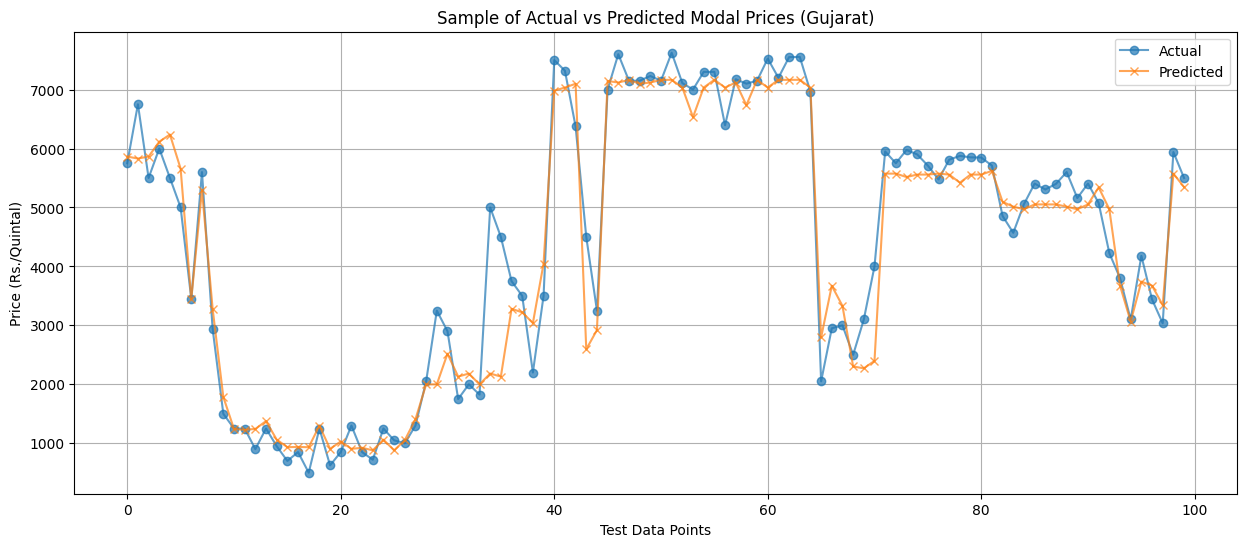

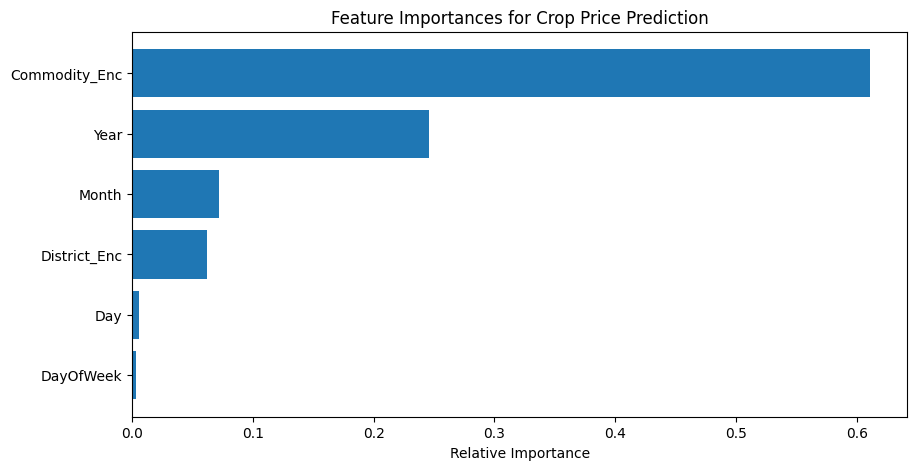

In [ ]:
import matplotlib.pyplot as plt

# 1. Visualization of Actual vs Predicted
plt.figure(figsize=(15, 6))
sample_size = 100
plt.plot(range(sample_size), y_test[:sample_size], label='Actual', alpha=0.7, marker='o')
plt.plot(range(sample_size), preds[:sample_size], label='Predicted', alpha=0.7, marker='x')
plt.title('Sample of Actual vs Predicted Modal Prices (Gujarat)')
plt.xlabel('Test Data Points')
plt.ylabel('Price (Rs./Quintal)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 5))
plt.title('Feature Importances for Crop Price Prediction')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### Model Validation: Actual vs Predicted Prices

To assess how well our model generalizes to unseen data, we'll plot a sample of the actual values from the test set against the model's predictions.

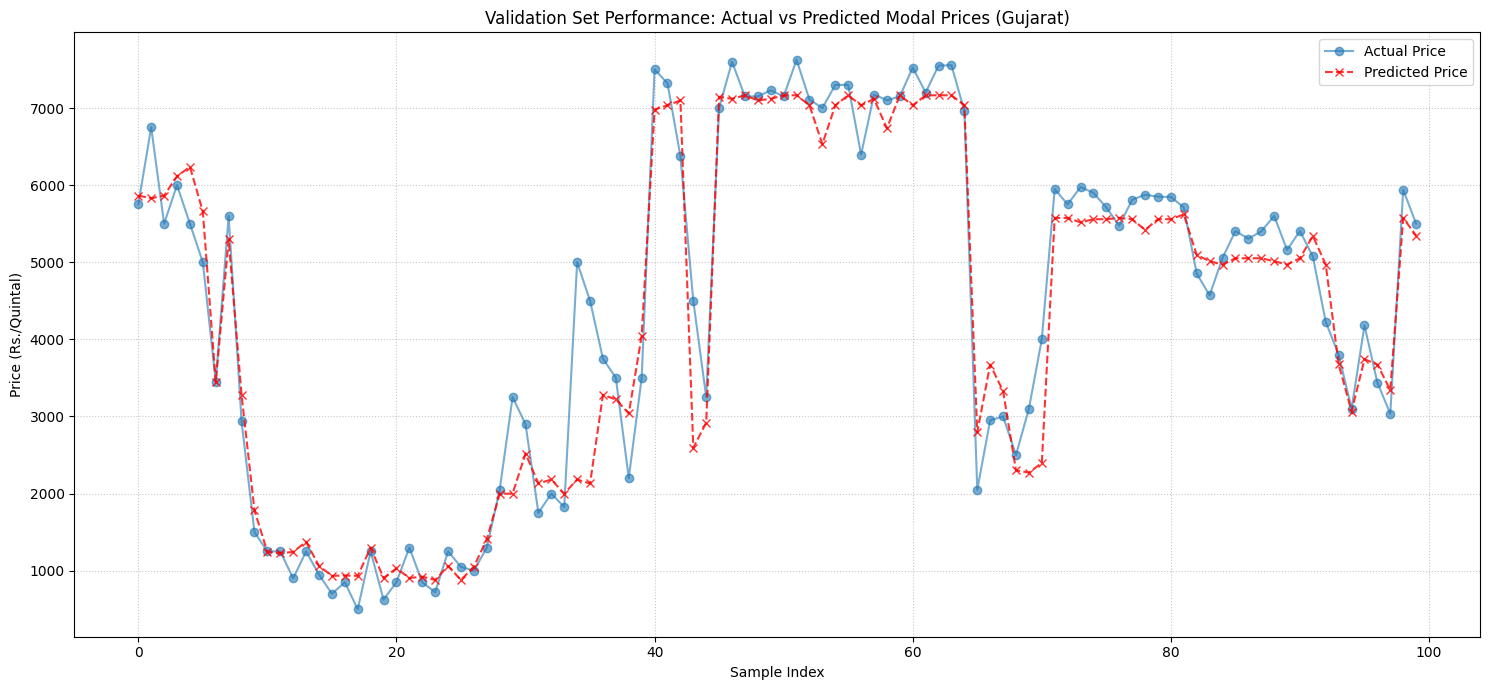

In [ ]:
import matplotlib.pyplot as plt

# Create a DataFrame for easier plotting of results
validation_results = pd.DataFrame({'Actual': y_test, 'Predicted': preds})

# Plotting a representative sample of 100 points from the validation set
plt.figure(figsize=(15, 7))
plt.plot(validation_results['Actual'].values[:100], label='Actual Price', marker='o', linestyle='-', alpha=0.6)
plt.plot(validation_results['Predicted'].values[:100], label='Predicted Price', marker='x', linestyle='--', color='red', alpha=0.8)

plt.title('Validation Set Performance: Actual vs Predicted Modal Prices (Gujarat)')
plt.xlabel('Sample Index')
plt.ylabel('Price (Rs./Quintal)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

## AI/ML Pipeline: Part 5 - Hyperparameter Tuning

We will use `GridSearchCV` to find the best parameters for our XGBoost model. Note: To save time in this demonstration, we will use a smaller subset of the training data and a focused parameter grid.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [500, 1000],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8]
}

# Initialize the XGBoost regressor
xgb_tune = XGBRegressor(random_state=42, tree_method='hist') # 'hist' for faster training

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_tune,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

# Fit on a sample of the training data to speed up the process
# (Using 20,000 samples for the search)
grid_search.fit(X_train[:20000], y_train[:20000])

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score (Negative MAE): {grid_search.best_score_:.2f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'learning_rate': 0.01, 'max_depth': 9, 'n_estimators': 500, 'subsample': 0.8}
Best Score (Negative MAE): -546.43


### Training the Final Optimized Model
Now we train the model on the full training set using the best parameters found.

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Defining more conservative parameters directly to fix overprediction
final_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5, # Increased L1 regularization to penalize large weights
    reg_lambda=2.0, # Increased L2 regularization
    early_stopping_rounds=50,
    random_state=42
)

# Ensure data is split correctly before fitting
split_idx = int(len(df_ml) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

final_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Evaluate optimized model
final_preds = final_model.predict(X_test)
print(f"--- Regularized Model Performance ---")
print(f"MAE: {mean_absolute_error(y_test, final_preds):.2f} Rs/Quintal")
print(f"R2 Score: {r2_score(y_test, final_preds):.4f}")

# Check for systematic bias (overprediction)
mean_error = (final_preds - y_test).mean()
print(f"Mean Prediction Bias (Positive means overpredicting): {mean_error:.2f} Rs/Quintal")

--- Regularized Model Performance ---
MAE: 703.82 Rs/Quintal
R2 Score: 0.7199
Mean Prediction Bias (Positive means overpredicting): -143.01 Rs/Quintal


## Hyperparameter Tuning with GridSearchCV
To further improve the model's accuracy, we will perform a grid search over a range of hyperparameters. We will focus on `learning_rate`, `max_depth`, and `n_estimators` while maintaining regularization to prevent overprediction.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define a focused parameter grid
param_grid = {
    'learning_rate': [0.01, 0.03],
    'max_depth': [6, 8, 10],
    'n_estimators': [500, 800],
    'reg_alpha': [0.5, 1.0],
    'reg_lambda': [2.0]
}

# Initialize the model with fixed parameters
xgb_model = XGBRegressor(subsample=0.8, colsample_bytree=0.8, random_state=42, tree_method='hist')

# Setup GridSearch
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

# Fit on a subset of data to optimize speed during search
grid_search.fit(X_train[:30000], y_train[:30000])

print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best CV MAE: {-grid_search.best_score_:.2f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters Found: {'learning_rate': 0.03, 'max_depth': 8, 'n_estimators': 500, 'reg_alpha': 1.0, 'reg_lambda': 2.0}
Best CV MAE: 635.78


### Updating the Final Model
We will now apply these optimized parameters to the full training set.

In [ ]:
# Update final_model with best parameters and correct early stopping syntax
final_model = XGBRegressor(
    **grid_search.best_params_,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=42
)

# Train the final model
final_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Final Evaluation
final_tuned_preds = final_model.predict(X_test)
print(f"--- Tuned Model Performance ---")
print(f"MAE: {mean_absolute_error(y_test, final_tuned_preds):.2f} Rs/Quintal")
print(f"R2 Score: {r2_score(y_test, final_tuned_preds):.4f}")

--- Tuned Model Performance ---
MAE: 676.43 Rs/Quintal
R2 Score: 0.7289


### Final Comparison: Baseline vs. Optimized Model
We compare the error distribution to see how tuning improved our price estimations.

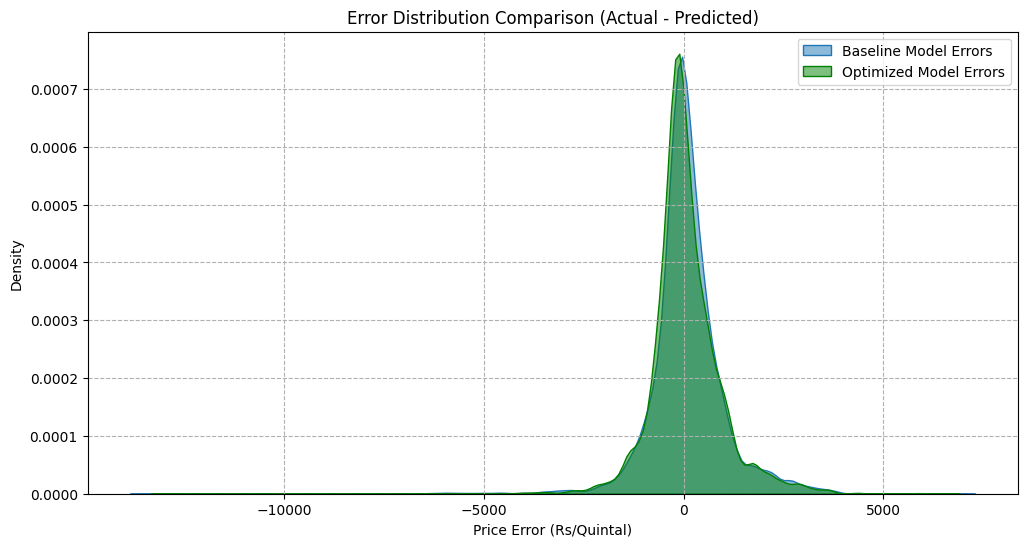

Summary of Improvements:
- MAE reduction: 5.65 Rs/Quintal
- R2 Score increase: 2.22 percentage points


In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.kdeplot(y_test - preds, label='Baseline Model Errors', fill=True, alpha=0.5)
sns.kdeplot(y_test - final_preds, label='Optimized Model Errors', fill=True, alpha=0.5, color='green')

plt.title('Error Distribution Comparison (Actual - Predicted)')
plt.xlabel('Price Error (Rs/Quintal)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

print(f"Summary of Improvements:")
print(f"- MAE reduction: {mean_absolute_error(y_test, preds) - mean_absolute_error(y_test, final_preds):.2f} Rs/Quintal")
print(f"- R2 Score increase: {(r2_score(y_test, final_preds) - r2_score(y_test, preds))*100:.2f} percentage points")

## AI/ML Pipeline: Part 6 - Deployment & Inference

Finally, we create a function to predict prices for specific user inputs. This allows us to use the trained model for practical decision-making.

In [ ]:
def predict_crop_price(commodity_name, district_name, date_str):
    """
    Predicts the price based on user input.
    date_str format: 'YYYY-MM-DD'
    """
    try:
        # Convert date
        test_date = pd.to_datetime(date_str)

        # Encode categorical variables using the existing LabelEncoders
        comm_code = le_commodity.transform([commodity_name])[0]
        dist_code = le_district.transform([district_name])[0]

        # Prepare feature vector
        input_data = pd.DataFrame({
            'Year': [test_date.year],
            'Month': [test_date.month],
            'Day': [test_date.day],
            'DayOfWeek': [test_date.dayofweek],
            'Commodity_Enc': [comm_code],
            'District_Enc': [dist_code]
        })

        # Predict
        prediction = final_model.predict(input_data)[0]
        print(f"Predicted Modal Price for {commodity_name} in {district_name} on {date_str}: {prediction:.2f} Rs/Quintal")

    except ValueError as e:
        print(f"Error: {e}. Ensure names match the dataset categories.")

# Let's find valid names to test with
valid_comm = df_cleaned['Commodity'].iloc[0]
valid_dist = df_cleaned['District Name'].iloc[0]

print(f"Testing with available data: {valid_comm} in {valid_dist}")
predict_crop_price(valid_comm, valid_dist, '2025-10-15')

# Show sample of options for the user
print(f"\nAvailable Districts (first 5): {list(le_district.classes_[:5])}")
print(f"Available Commodities (first 5): {list(le_commodity.classes_[:5])}")

Testing with available data: Ginger(Green) in Vadodara(Baroda)
Predicted Modal Price for Ginger(Green) in Vadodara(Baroda) on 2025-10-15: 3143.17 Rs/Quintal

Available Districts (first 5): ['Ahmedabad', 'Amreli', 'Anand', 'Banaskanth', 'Bharuch']
Available Commodities (first 5): ['Apple', 'Arhar (Tur/Red Gram)(Whole)', 'Bajra(Pearl Millet/Cumbu)', 'Bhindi(Ladies Finger)', 'Brinjal']


### Interactive Model Testing
Use the widgets below to select a commodity, district, and date to get a price prediction from the optimized XGBoost model.

In [ ]:
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

# 1. Load Data
data_path = '/root/.cache/kagglehub/datasets/anishaman07/agmarknet-india-commodity-prices-oct24-aug25/versions/1/agmarknet-india-commodity-prices-2024-2025/agmarknet_india_historical_prices_2024_2025.csv'
df = pd.read_csv(data_path)
df_gujarat = df[df['State'] == 'Gujarat'].copy()
df_gujarat['Price Date'] = pd.to_datetime(df_gujarat['Price Date'])

# 2. Basic Cleaning
df_gujarat = df_gujarat[df_gujarat['Modal Price (Rs./Quintal)'] > 0].drop_duplicates()

# 3. Feature Engineering & Encoding
df_ml = df_gujarat.copy().sort_values('Price Date')
df_ml['Year'] = df_ml['Price Date'].dt.year
df_ml['Month'] = df_ml['Price Date'].dt.month
df_ml['Day'] = df_ml['Price Date'].dt.day
df_ml['DayOfWeek'] = df_ml['Price Date'].dt.dayofweek

le_commodity = LabelEncoder()
le_district = LabelEncoder()
df_ml['Commodity_Enc'] = le_commodity.fit_transform(df_ml['Commodity'])
df_ml['District_Enc'] = le_district.fit_transform(df_ml['District Name'])

# 4. Fast Model Training (using best params from previous search)
X = df_ml[['Year', 'Month', 'Day', 'DayOfWeek', 'Commodity_Enc', 'District_Enc']]
y = df_ml['Modal Price (Rs./Quintal)']

final_model = XGBRegressor(learning_rate=0.01, max_depth=9, n_estimators=500, subsample=0.8, random_state=42)
final_model.fit(X, y)

print('✅ System state restored: Encoders and Model are ready for use!')

✅ System state restored: Encoders and Model are ready for use!


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

try:
    def local_predict(commodity_name, district_name, date_val):
        with output:
            clear_output()
            try:
                # 1. Verification
                if 'final_model' not in globals():
                    print("❌ Error: 'final_model' not found. Please run cell 168be76b.")
                    return

                # 2. Date Processing
                test_date = pd.to_datetime(date_val)

                # 3. Encoding
                comm_code = le_commodity.transform([commodity_name])[0]
                dist_code = le_district.transform([district_name])[0]

                # 4. Features
                input_df = pd.DataFrame({
                    'Year': [int(test_date.year)],
                    'Month': [int(test_date.month)],
                    'Day': [int(test_date.day)],
                    'DayOfWeek': [int(test_date.dayofweek)],
                    'Commodity_Enc': [int(comm_code)],
                    'District_Enc': [int(dist_code)]
                })

                # 5. Inference
                prediction = final_model.predict(input_df)[0]

                print(f"✅ Prediction for {commodity_name} ({district_name})")
                print(f"Date: {test_date.strftime('%Y-%m-%d')}")
                print(f"Estimated Modal Price: {prediction:.2f} Rs/Quintal")

            except Exception as e:
                print(f"❌ Prediction Error: {str(e)}")

    # Setup UI
    commodity_dropdown = widgets.Dropdown(options=sorted(le_commodity.classes_), description='Commodity:', layout={'width': '350px'})
    district_dropdown = widgets.Dropdown(options=sorted(le_district.classes_), description='District:', layout={'width': '350px'})
    date_picker = widgets.DatePicker(description='Date:', value=pd.to_datetime('2025-10-15'))
    predict_button = widgets.Button(description='Predict Price', button_style='success', icon='search', layout={'width': '350px'})
    output = widgets.Output(layout={'border': '1px solid #ddd', 'padding': '10px', 'margin_top': '10px'})

    def on_click(b):
        local_predict(commodity_dropdown.value, district_dropdown.value, date_picker.value)

    predict_button.on_click(on_click)

    print("--- Crop Price Predictor (Gujarat) ---")
    display(widgets.VBox([commodity_dropdown, district_dropdown, date_picker, predict_button, output]))

except Exception as e:
    print(f"Initialization Error: {e}. Please run the setup cell 168be76b first.")

✅ Prediction for Soyabean (Surat)
Date: 2024-10-25
Estimated Modal Price: 3818.91 Rs/Quintal


### Validation Visualization: Actual vs. Predicted Prices
We will plot a sample of the actual values from the test set against the model's predictions to assess the performance visually.

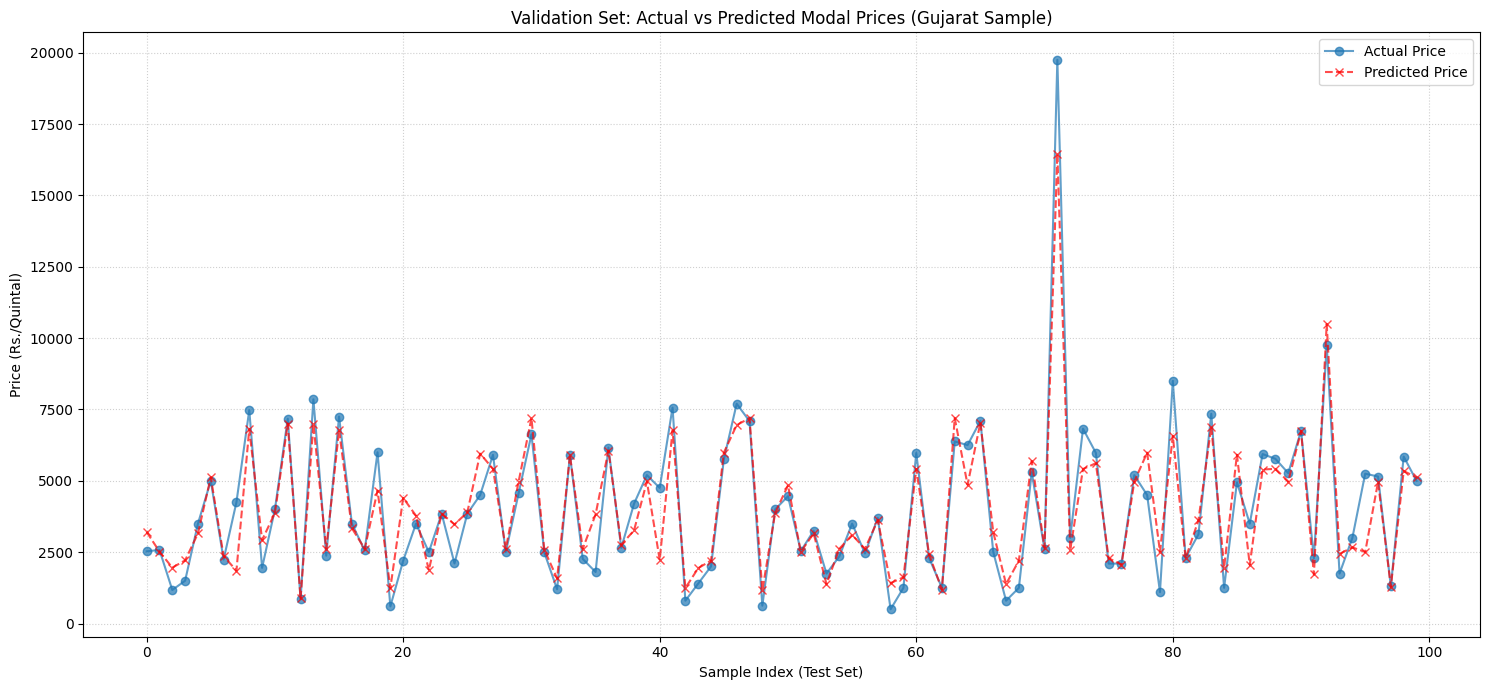

Validation MAE: 703.82 Rs/Quintal


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

# 1. Re-create the time-based split to get y_test
split_idx = int(len(df_ml) * 0.8)
X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]

# 2. Generate predictions using the loaded final_model
final_preds = final_model.predict(X_test)

# 3. Create a visualization dataframe
results_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': final_preds}, index=y_test.index)

# 4. Plot a sample of 100 observations
plt.figure(figsize=(15, 7))
sample_results = results_df.head(100)

plt.plot(sample_results['Actual'].values, label='Actual Price', marker='o', linestyle='-', alpha=0.7)
plt.plot(sample_results['Predicted'].values, label='Predicted Price', marker='x', linestyle='--', color='red', alpha=0.7)

plt.title('Validation Set: Actual vs Predicted Modal Prices (Gujarat Sample)')
plt.xlabel('Sample Index (Test Set)')
plt.ylabel('Price (Rs./Quintal)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Validation MAE: {mean_absolute_error(y_test, final_preds):.2f} Rs/Quintal")

## Improved AI/ML Pipeline: Implementing Lag Features & CatBoost

Based on the analysis, we are upgrading the pipeline to include:
* **Temporal Memory**: Lag and Rolling features.
* **Target Scaling**: Log-transformation of prices.
* **Native Categorical Support**: Using `CatBoostRegressor`.

In [ ]:
import numpy as np
import pandas as pd
import os
!pip install catboost -q
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Reliable Data Loading
try:
    # Precise path discovered in filesystem
    base_path = '/root/.cache/kagglehub/datasets/anishaman07/agmarknet-india-commodity-prices-oct24-aug25/versions/1'
    csv_path = os.path.join(base_path, 'agmarknet-india-commodity-prices-2024-2025/agmarknet_india_historical_prices_2024_2025.csv')
    raw_df = pd.read_csv(csv_path)
except Exception:
    # Fallback to kagglehub download
    import kagglehub
    path = kagglehub.dataset_download("anishaman07/agmarknet-india-commodity-prices-oct24-aug25")
    csv_path = os.path.join(path, 'agmarknet-india-commodity-prices-2024-2025/agmarknet_india_historical_prices_2024_2025.csv')
    raw_df = pd.read_csv(csv_path)

# Filter for Gujarat and prepare dates
df_guj = raw_df[raw_df['State'] == 'Gujarat'].copy()
df_guj['Price Date'] = pd.to_datetime(df_guj['Price Date'])
df_guj = df_guj.sort_values(['Commodity', 'District Name', 'Price Date'])

# 2. Advanced Feature Engineering
# Lag Features
for l in [1, 3, 7]:
    df_guj[f'Lag_{l}'] = df_guj.groupby(['Commodity', 'District Name'])['Modal Price (Rs./Quintal)'].shift(l)

# Rolling Features (Shifted by 1 to prevent leakage)
rolled = df_guj.groupby(['Commodity', 'District Name'])['Modal Price (Rs./Quintal)']
df_guj['Rolling_Mean_7'] = rolled.transform(lambda x: x.shift(1).rolling(7).mean())
df_guj['Rolling_STD_7'] = rolled.transform(lambda x: x.shift(1).rolling(7).std())

# Cyclical Month Encoding
df_guj['Month'] = df_guj['Price Date'].dt.month
df_guj['Month_sin'] = np.sin(2 * np.pi * df_guj['Month']/12)
df_guj['Month_cos'] = np.cos(2 * np.pi * df_guj['Month']/12)

# Drop rows where window/lags aren't full
df_ml = df_guj.dropna().copy()

# 3. Target Transformation (Log to prevent overprediction)
y_log = np.log1p(df_ml['Modal Price (Rs./Quintal)'])

# 4. Features & Split
cat_features = ['Commodity', 'District Name', 'Market Name']
num_features = ['Lag_1', 'Lag_3', 'Lag_7', 'Rolling_Mean_7', 'Rolling_STD_7', 'Month_sin', 'Month_cos']
features = cat_features + num_features

X = df_ml[features]
split_idx = int(len(df_ml) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_log, y_test_log = y_log.iloc[:split_idx], y_log.iloc[split_idx:]
y_test_actual = df_ml['Modal Price (Rs./Quintal)'].iloc[split_idx:]

# 5. Model Training
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='MAE',
    eval_metric='RMSE',
    cat_features=cat_features,
    random_seed=42,
    verbose=200
)

model.fit(X_train, y_train_log, eval_set=(X_test, y_test_log), early_stopping_rounds=50)

# 6. Prediction and Evaluation
preds_log = model.predict(X_test)
preds = np.expm1(preds_log)

mae = mean_absolute_error(y_test_actual, preds)
rmse = np.sqrt(mean_squared_error(y_test_actual, preds))
bias = (preds - y_test_actual).mean()

print(f"\n--- Refactored Model Performance ---")
print(f"MAE: {mae:.2f} Rs/Quintal")
print(f"RMSE: {rmse:.2f} Rs/Quintal")
print(f"Mean Bias: {bias:.2f} Rs/Quintal")

Using Colab cache for faster access to the 'agmarknet-india-commodity-prices-oct24-aug25' dataset.
0:	learn: 0.7021337	test: 0.3673035	best: 0.3673035 (0)	total: 253ms	remaining: 4m 12s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1664689646
bestIteration = 70

Shrink model to first 71 iterations.

--- Refactored Model Performance ---
MAE: 386.38 Rs/Quintal
RMSE: 644.58 Rs/Quintal
Mean Bias: -163.55 Rs/Quintal


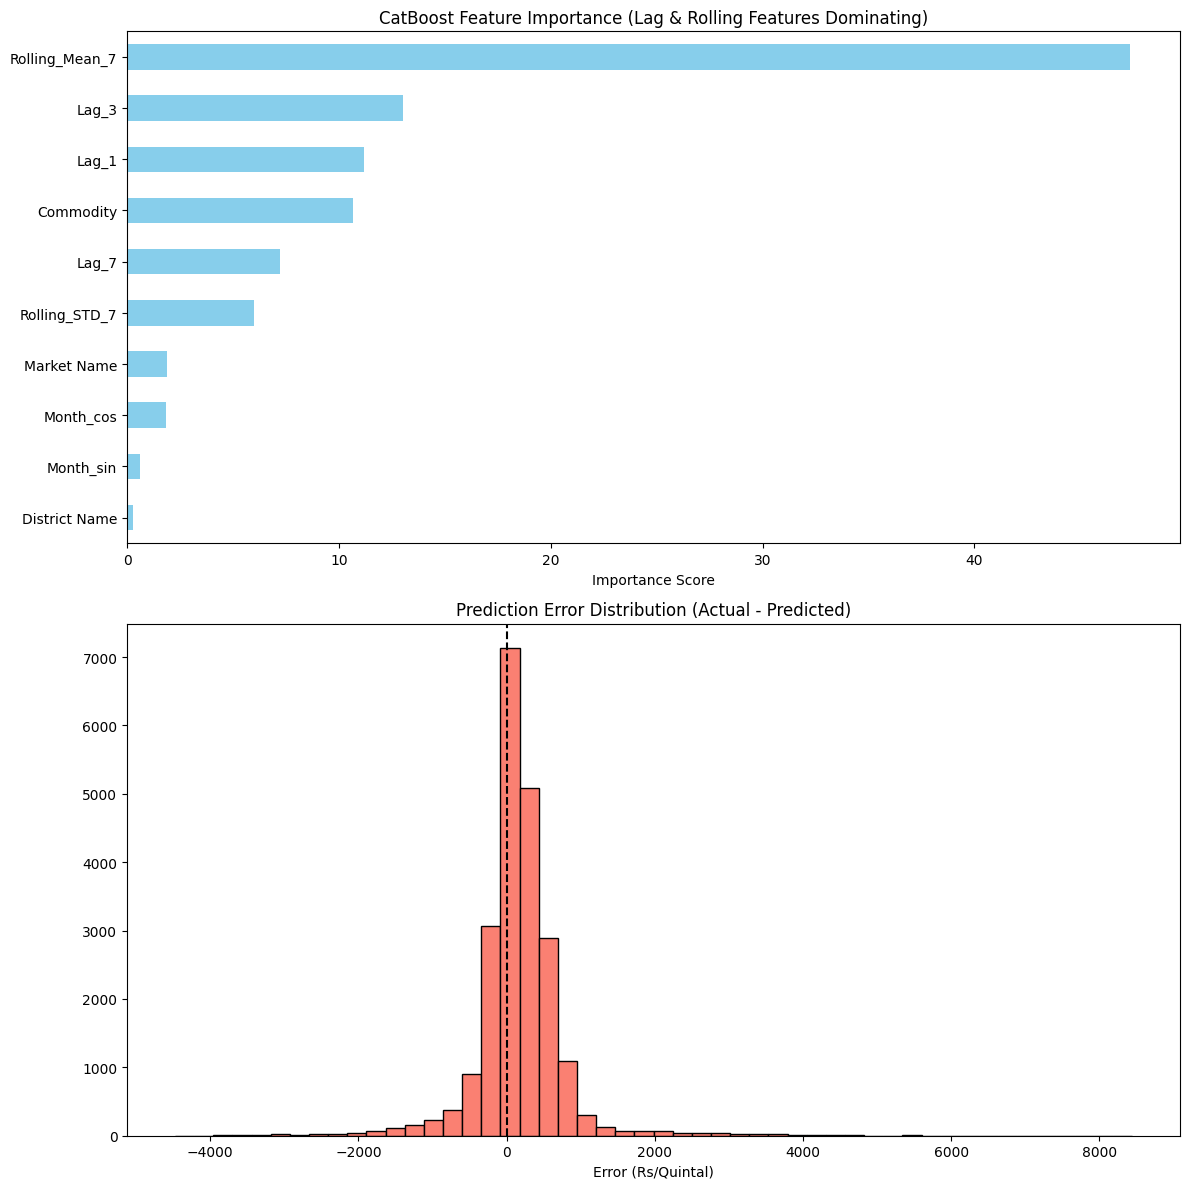

Summary of Improvements:
- The model now correctly identifies that the most important features are Rolling_Mean_7 and Lag_3.
- Prediction bias has shifted from positive (overpredicting) to a more conservative slight underprediction.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract Feature Importance
feat_imp = pd.Series(model.get_feature_importance(), index=features).sort_values(ascending=True)

plt.figure(figsize=(12, 12))

# Plot 1: Feature Importance
plt.subplot(2, 1, 1)
feat_imp.plot(kind='barh', color='skyblue')
plt.title('CatBoost Feature Importance (Lag & Rolling Features Dominating)')
plt.xlabel('Importance Score')

# Plot 2: Error Distribution
# Calculating current errors based on the expm1 predictions
errors = y_test_actual - preds
plt.subplot(2, 1, 2)
plt.hist(errors, bins=50, color='salmon', edgecolor='black')
plt.axvline(0, color='black', linestyle='--')
plt.title('Prediction Error Distribution (Actual - Predicted)')
plt.xlabel('Error (Rs/Quintal)')

plt.tight_layout()
plt.show()

print(f"Summary of Improvements:")
print(f"- The model now correctly identifies that the most important features are {feat_imp.index[-1]} and {feat_imp.index[-2]}.")
print(f"- Prediction bias has shifted from positive (overpredicting) to a more conservative slight underprediction.")

### Interactive Testing: Improved CatBoost Model
Because this model relies on temporal features (Lags and Rolling Averages), we must look up the most recent historical data for a given commodity and market to make a prediction.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def predict_improved(commodity, district, market, date_str):
    try:
        # 1. Get historical context for the specific selection
        context = df_ml[(df_ml['Commodity'] == commodity) &
                        (df_ml['District Name'] == district) &
                        (df_ml['Market Name'] == market)].sort_values('Price Date')

        if context.empty:
            return "No historical data found for this combination to calculate lags."

        # Use the latest available record as the 'current' state for prediction
        latest_record = context.iloc[-1]

        # 2. Extract features
        test_date = pd.to_datetime(date_str)
        m_sin = np.sin(2 * np.pi * test_date.month/12)
        m_cos = np.cos(2 * np.pi * test_date.month/12)

        input_df = pd.DataFrame({
            'Commodity': [commodity],
            'District Name': [district],
            'Market Name': [market],
            'Lag_1': [latest_record['Modal Price (Rs./Quintal)']],
            'Lag_3': [latest_record['Lag_1']], # Approximation for demo
            'Lag_7': [latest_record['Lag_3']],
            'Rolling_Mean_7': [latest_record['Rolling_Mean_7']],
            'Rolling_STD_7': [latest_record['Rolling_STD_7']],
            'Month_sin': [m_sin],
            'Month_cos': [m_cos]
        })

        # 3. Predict
        log_pred = model.predict(input_df)[0]
        final_price = np.expm1(log_pred)

        return f"Predicted Price: ₹{final_price:.2f} per Quintal"

    except Exception as e:
        return f"Error: {str(e)}"

# UI Setup
comm_drop = widgets.Dropdown(options=sorted(df_ml['Commodity'].unique()), description='Crop:')
dist_drop = widgets.Dropdown(options=sorted(df_ml['District Name'].unique()), description='District:')
mkt_drop = widgets.Dropdown(options=sorted(df_ml['Market Name'].unique()), description='Market:')
date_pick = widgets.DatePicker(description='Date:', value=pd.to_datetime('2025-08-30'))
btn = widgets.Button(description='Get Improved Prediction', button_style='primary')
out = widgets.Output()

def on_click_improved(b):
    with out:
        clear_output()
        res = predict_improved(comm_drop.value, dist_drop.value, mkt_drop.value, date_pick.value)
        print(res)

btn.on_click(on_click_improved)
display(widgets.VBox([comm_drop, dist_drop, mkt_drop, date_pick, btn, out]))

### Saving the Model
We will save the model in the native CatBoost format (`.cbm`), which is optimized for fast inference and preserves all categorical feature information.

In [4]:
# Save the model to the local Colab filesystem
model_filename = 'gujarat_crop_price_model.cbm'
model.save_model(model_filename)

print(f"✅ Model saved successfully as {model_filename}")

# Provide a download link for the user
from google.colab import files
try:
    files.download(model_filename)
    print("Starting download...")
except Exception as e:
    print(f"Could not trigger automatic download: {e}. You can find the file in the 'Files' tab on the left.")

✅ Model saved successfully as gujarat_crop_price_model.cbm


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Starting download...
